# Proyecto: Clasificación de sentimientos para lenguajes naturales a través de vectorización de palabras.

##### Importación de bibliotecas para archivos separados por comas y tokenizador para lenguajes naturales

In [ ]:
import csv
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

##### Importación de bibliotecas de uso general

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn

from string import punctuation
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

### Preprocesamiento de datos

##### Lectura del archivo con los tweets a clasificar y división de la base en los tweets con su respectivo sentimiento.

In [ ]:
stop_words = stopwords.words('english')

data = []

with open('training.csv', 'r') as file:
    reader = csv.reader(file)
    data = [ row for row in reader ]
    data.pop(0)

tweets = [ row[0] for row in data ]
sentimientos = [ row[1] for row in data ]

#sentimientos

##### Nuestra función casera para tokenizar el texto en el lenguaje Inglés y filtrar palabras sin relevancia para el entrenamiento

In [ ]:
def tokenize(tweet):
    words = word_tokenize(tweet)
    return [word.lower() for word in words if word.isalnum() and word.lower() not in stop_words]

tokenized_tweets = [tokenize(tweet) for tweet in tweets]

filtered_tweets = []

for tweet in tokenized_tweets:
  filtered_tweet = [word for word in tweet if word not in stop_words]
  filtered_tweets.append(filtered_tweet)

##### Creación del modelo W2V (Word To Vector) para la posterior transformación de nuestros datos (palabras) a vectores de tamaño idéntico

In [ ]:
model = Word2Vec(sentences=filtered_tweets, vector_size=1000, epochs=50, min_count=2, workers=4)

##### Prueba rápida para verificar el uso y función de nuestro modelo W2V

In [ ]:
similar_words = model.wv.most_similar("happy", topn=20)
similar_words

[('ecstatic', 0.4205802083015442),
 ('hopeful', 0.39913102984428406),
 ('proud', 0.38414835929870605),
 ('contented', 0.3744587302207947),
 ('invaded', 0.3639903962612152),
 ('positive', 0.359040230512619),
 ('peaceful', 0.3569018840789795),
 ('heartbroken', 0.3561936914920807),
 ('known', 0.355060875415802),
 ('excited', 0.3511756360530853),
 ('tranquil', 0.34867459535598755),
 ('sinking', 0.3484693467617035),
 ('enjoying', 0.34422993659973145),
 ('admired', 0.3433406352996826),
 ('humbled', 0.3421418070793152),
 ('motivated', 0.34020328521728516),
 ('thankful', 0.34006378054618835),
 ('level', 0.33691278100013733),
 ('bummed', 0.3364545702934265),
 ('fulfilled', 0.33372899889945984)]

##### Creación de nuestra función para vectorizar texto en Inglés, en nuestro caso Tweets. También usamos el clasificador de regresión logística y evaluamos su rendimiento

Precision :  0.6096875
Recall :  0.6096875
Accuracy Score :  0.6096875
F1 Score :  0.6096875


Text(95.72222222222221, 0.5, 'Reality')

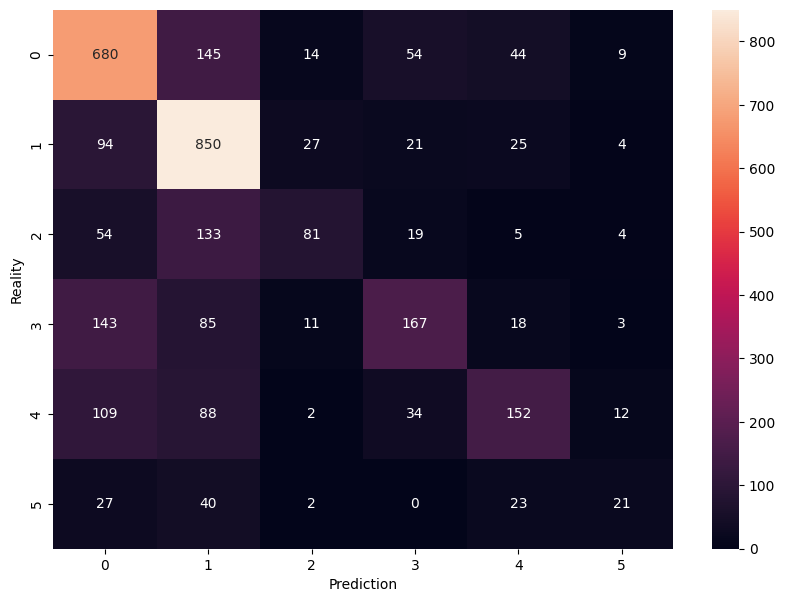

In [ ]:
def vectorize_tweets(tweets, model):
    vectors = []
    for tweet in tweets:
        # Filtra las palabras que no están en el modelo Word2Vec
        valid_words = [word for word in tweet if word in model.wv]
        if valid_words:
            # Calcula el promedio de los vectores de palabras
            vector = np.mean([model.wv[word] for word in valid_words], axis=0)
            vectors.append(vector)
        else:
            # Si no hay palabras válidas, agrega un vector de ceros
            vectors.append(np.zeros(model.vector_size))

    return np.array(vectors)

# Vectores de características
X = vectorize_tweets(tokenized_tweets, model)

# División del conjunto de datos
X_train, X_test, y_train, y_test = train_test_split(X, sentimientos, test_size=0.2, random_state=42)

# Entrenamiento del clasificador (regresión logística)
classifier_handmade = LogisticRegression(random_state=42, max_iter=500)
classifier_handmade.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
predictions_handmade = classifier_handmade.predict(X_test)

# Evaluación del rendimiento
#accuracy_handmade = accuracy_score(y_test, predictions_handmade)
#print(f'Precisión del clasificador casero: {accuracy * 100:.2f}%')
accuracy_handmade = accuracy_score(y_test, predictions_handmade)
precision_handmade = precision_score(y_test, predictions_handmade, average='micro')
print("Precision : ", precision_handmade)
print("Recall : ", recall_score(y_test, predictions_handmade, average='micro'))
print("Accuracy Score : ", accuracy_handmade)
print("F1 Score : ", f1_score(y_test, predictions_handmade, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_handmade), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Probamos el rendimiento con TfidfVectorizer en lugar de nuestra vectorización casera

Precision :  0.8689148112898825
Recall :  0.8503125
Accuracy Score :  0.8503125
F1 Score :  0.8503125


Text(95.72222222222221, 0.5, 'Reality')

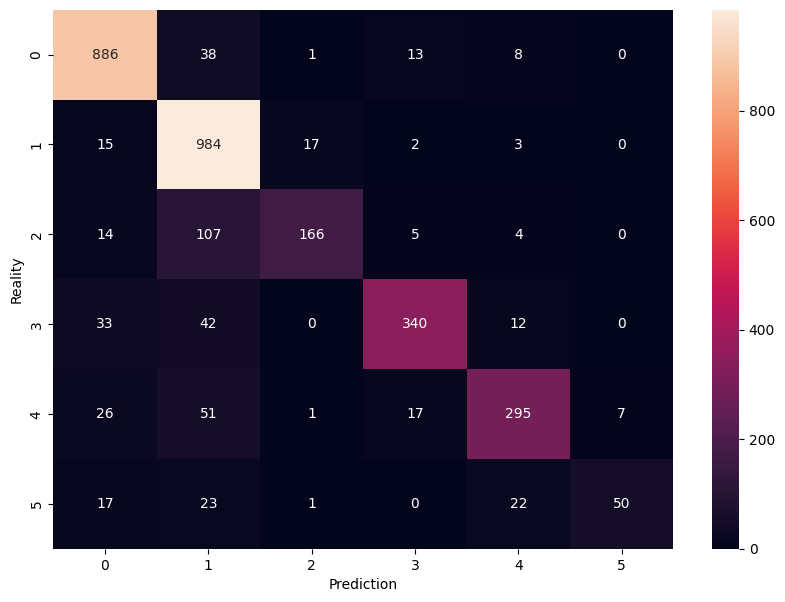

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform([ ' '.join(tok) for tok in tokenized_tweets])

X_train, X_test, y_train, y_test = train_test_split(X, sentimientos, test_size=0.2, random_state=42)

# Entrenamiento del clasificador (regresión logística)
classifier_handmade.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
predictions_tf = classifier_handmade.predict(X_test)

# Evaluación del rendimiento
#accuracy = accuracy_score(y_test, predictions)
#print(f'Precisión del clasificador: {accuracy * 100:.2f}%')
accuracy_tf = accuracy_score(y_test, predictions_tf)
precision_tf = precision_score(y_test, predictions_tf, average='macro')
print("Precision : ", precision_tf)
print("Recall : ", recall_score(y_test, predictions_tf, average='micro'))
print("Accuracy Score : ", accuracy_tf)
print("F1 Score : ", f1_score(y_test, predictions_tf, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_tf), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

#### Ahora probaremos con una serie de clasificadores para ver cuál nos da la mejor predicción

##### Clasificador Naibe Bayes

Precision :  0.655625
Recall :  0.655625
Accuracy Score :  0.8503125
F1 Score :  0.655625


Text(95.72222222222221, 0.5, 'Reality')

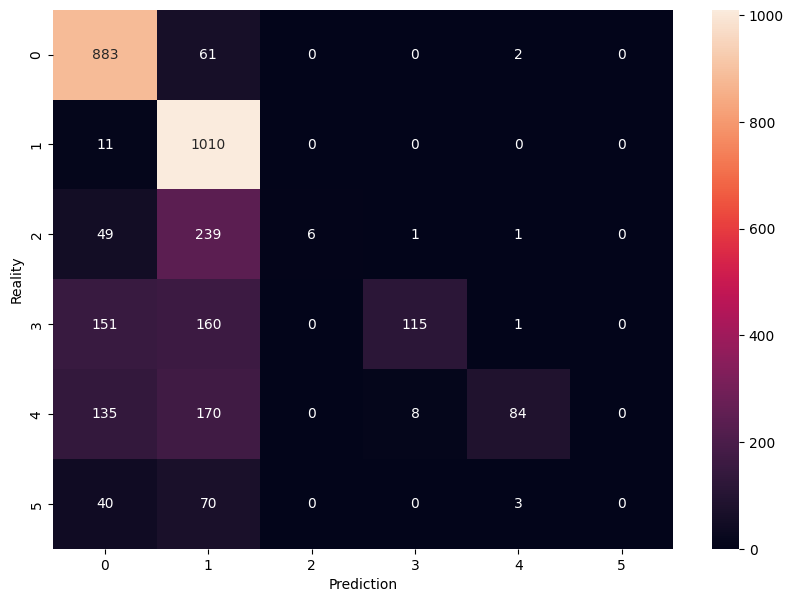

In [ ]:
from sklearn.naive_bayes import MultinomialNB

classifier = MultinomialNB()
classifier.fit(X_train, y_train)

# Predicciones de NB
predictions_nb = classifier.predict(X_test)

# Rendimiento
accuracy_nb = accuracy_score(y_test, predictions_tf)
precision_nb = precision_score(y_test, predictions_nb, average='micro')
print("Precision : ", precision_nb)
print("Recall : ", recall_score(y_test, predictions_nb, average='micro'))
print("Accuracy Score : ", accuracy_nb)
print("F1 Score : ", f1_score(y_test, predictions_nb, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_nb), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador K-Nearest-Neighbors

Precision :  0.7759375
Recall :  0.7759375
Accuracy Score :  0.8496875
F1 Score :  0.7759375


Text(95.72222222222221, 0.5, 'Reality')

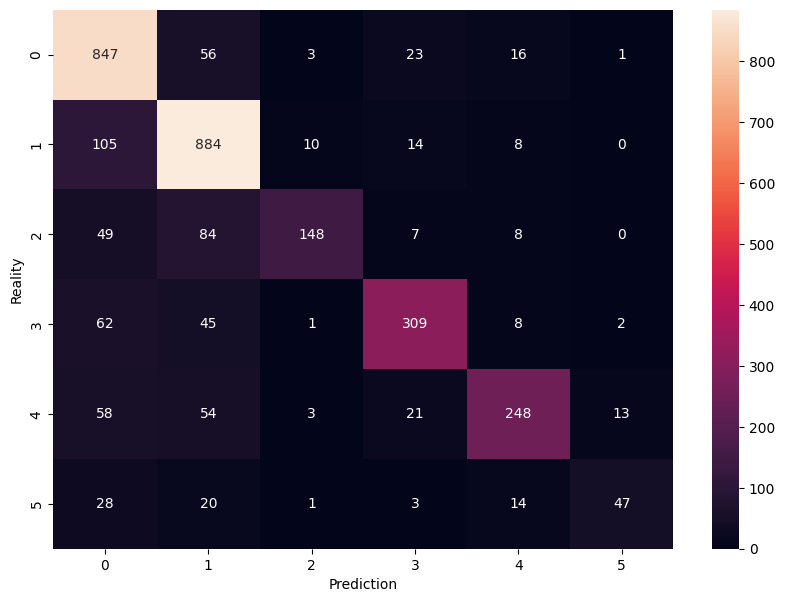

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier()
classifier.fit(X_train, y_train)

# Predicciones en el conjunto de prueba
predictions_knn = classifier.predict(X_test)

# Evaluación del rendimiento
accuracy_knn = accuracy_score(y_test, predictions_tf)
precision_knn = precision_score(y_test, predictions_knn, average='micro')
print("Precision : ", precision_knn)
print("Recall : ", recall_score(y_test, predictions_knn, average='micro'))
print("Accuracy Score : ", accuracy_knn)
print("F1 Score : ", f1_score(y_test, predictions_knn, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_knn), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Gradient Boosting

Precision :  0.8340625
Recall :  0.8340625
Accuracy Score :  0.8340625
F1 Score :  0.8340625


Text(95.72222222222221, 0.5, 'Reality')

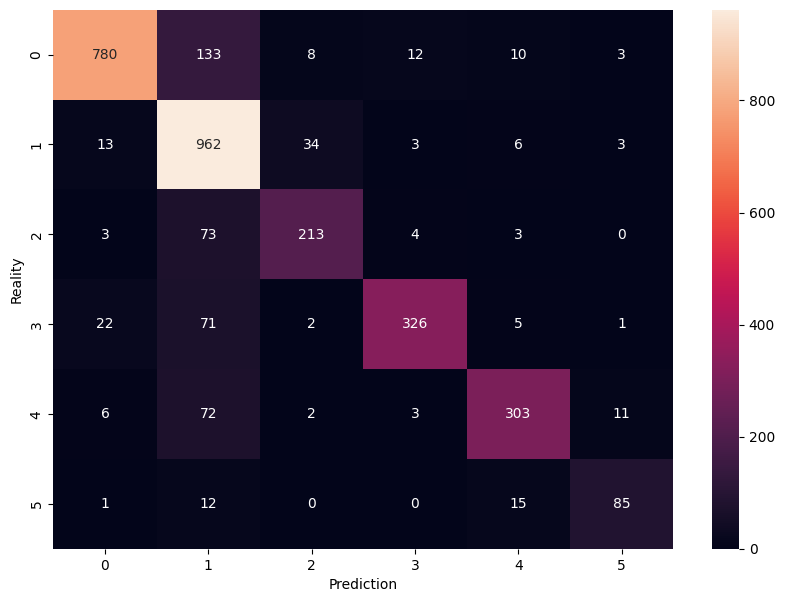

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

classifier = GradientBoostingClassifier()
classifier.fit(X_train, y_train)

# Predicciones
predictions_gb = classifier.predict(X_test)

# Rendimiento
accuracy_gb = accuracy_score(y_test, predictions_gb)
precision_gb = precision_score(y_test, predictions_gb, average='micro')
print("Precision : ", precision_gb)
print("Recall : ", recall_score(y_test, predictions_gb, average='micro'))
print("Accuracy Score : ", accuracy_gb)
print("F1 Score : ", f1_score(y_test, predictions_gb, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_gb), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Multi Layer Perceptron

Precision :  0.84875
Recall :  0.84875
Accuracy Score :  0.84875
F1 Score :  0.84875


Text(95.72222222222221, 0.5, 'Reality')

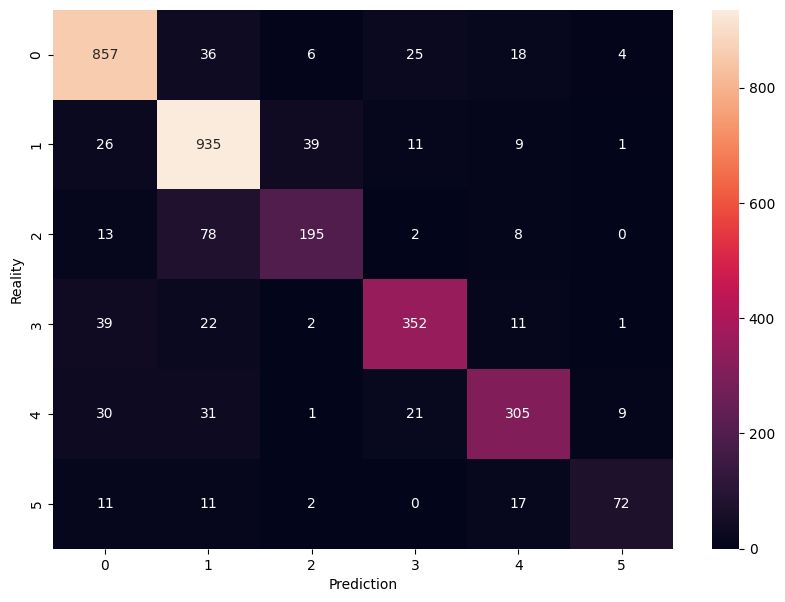

In [ ]:
from sklearn.neural_network import MLPClassifier

classifier = MLPClassifier()
classifier.fit(X_train, y_train)

# Predicciones
predictions_mlp = classifier.predict(X_test)

# Rendimiento
accuracy_mlp = accuracy_score(y_test, predictions_mlp)
precision_mlp = precision_score(y_test, predictions_mlp, average='micro')
print("Precision : ", precision_mlp)
print("Recall : ", recall_score(y_test, predictions_mlp, average='micro'))
print("Accuracy Score : ", accuracy_mlp)
print("F1 Score : ", f1_score(y_test, predictions_mlp, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_mlp), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Simple Perceptron

Precision :  0.8621875
Recall :  0.8621875
Accuracy Score :  0.8621875
F1 Score :  0.8621875


Text(95.72222222222221, 0.5, 'Reality')

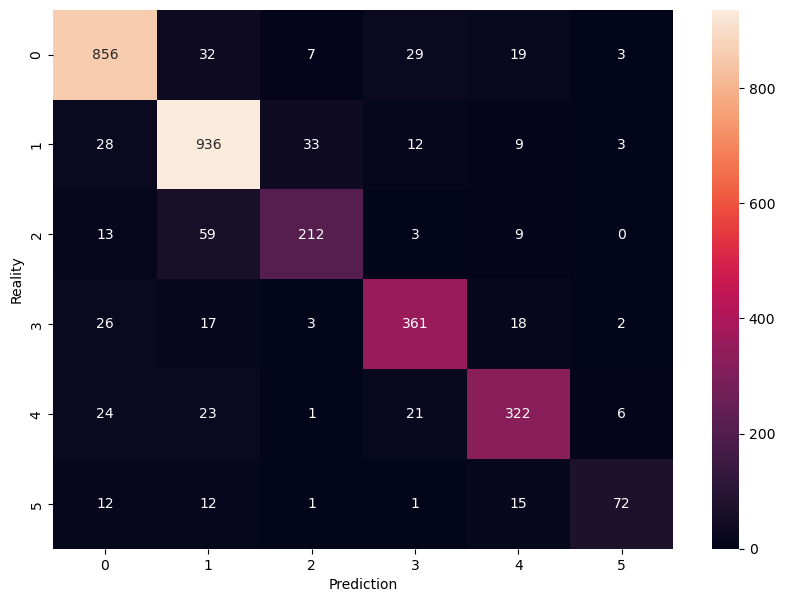

In [ ]:
from sklearn.linear_model import Perceptron

classifier = Perceptron()
classifier.fit(X_train, y_train)

# Predicciones
predictions_sp = classifier.predict(X_test)

# Rendimiento
accuracy_sp = accuracy_score(y_test, predictions_sp)
precision_sp = precision_score(y_test, predictions_sp, average='micro')
print("Precision : ", precision_sp)
print("Recall : ", recall_score(y_test, predictions_sp, average='micro'))
print("Accuracy Score : ", accuracy_sp)
print("F1 Score : ", f1_score(y_test, predictions_sp, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_sp), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Decision Trees

Precision :  0.8671875
Recall :  0.8671875
Accuracy Score :  0.8671875
F1 Score :  0.8671875


Text(95.72222222222221, 0.5, 'Reality')

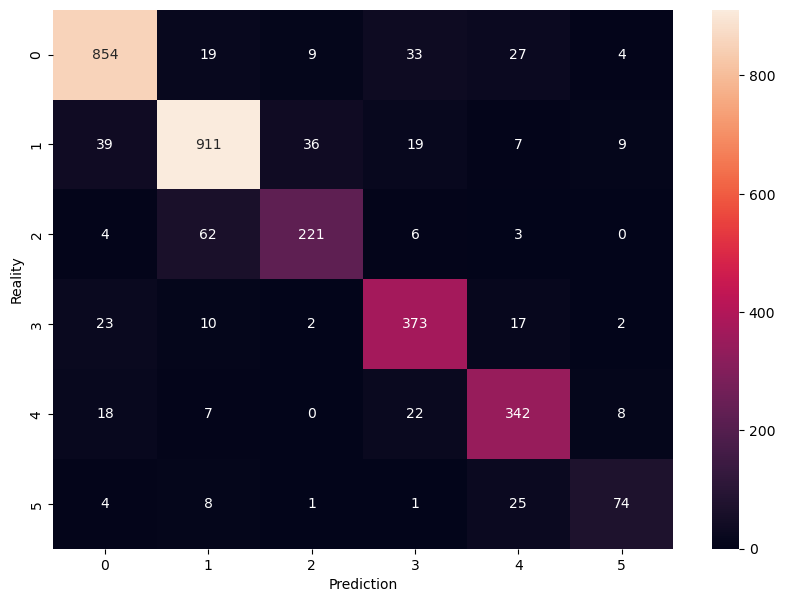

In [ ]:
from sklearn import tree

classifier = tree.DecisionTreeClassifier()
classifier.fit(X_train, y_train)

# Predicciones
predictions_dt = classifier.predict(X_test)

# Rendimiento
accuracy_dt = accuracy_score(y_test, predictions_dt)
precision_dt = precision_score(y_test, predictions_dt, average='micro')
print("Precision : ", precision_dt)
print("Recall : ", recall_score(y_test, predictions_dt, average='micro'))
print("Accuracy Score : ", accuracy_dt)
print("F1 Score : ", f1_score(y_test, predictions_dt, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_dt), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Passive Aggressive

Precision :  0.866875
Recall :  0.866875
Accuracy Score :  0.866875
F1 Score :  0.866875


Text(95.72222222222221, 0.5, 'Reality')

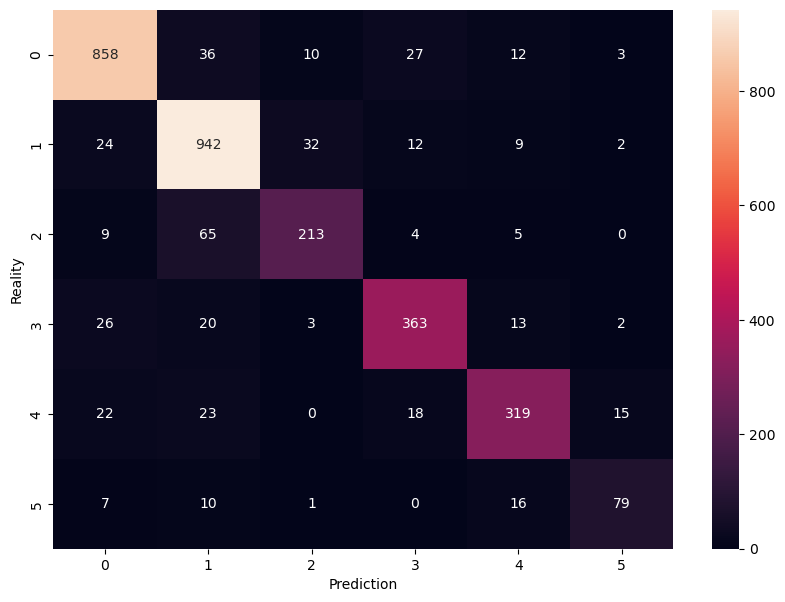

In [ ]:
from sklearn.linear_model import PassiveAggressiveClassifier

classifier = PassiveAggressiveClassifier(loss='squared_hinge')
classifier.fit(X_train, y_train)

# Predicciones
predictions_pa = classifier.predict(X_test)

# Rendimiento
accuracy_pa = accuracy_score(y_test, predictions_pa)
precision_pa = precision_score(y_test, predictions_pa, average='micro')
print("Precision : ", precision_pa)
print("Recall : ", recall_score(y_test, predictions_pa, average='micro'))
print("Accuracy Score : ", accuracy_pa)
print("F1 Score : ", f1_score(y_test, predictions_pa, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_pa), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Bagging

Precision :  0.8803125
Recall :  0.8803125
Accuracy Score :  0.8803125
F1 Score :  0.8803125


Text(95.72222222222221, 0.5, 'Reality')

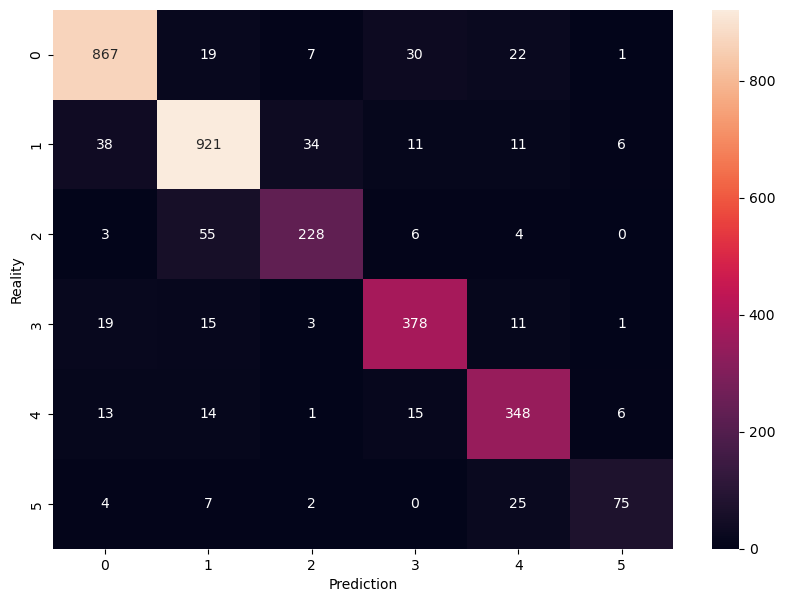

In [ ]:
from sklearn.ensemble import BaggingClassifier

classifier = BaggingClassifier()
classifier.fit(X_train, y_train)

# Predicciones
predictions_b = classifier.predict(X_test)

# Rendimiento
accuracy_b = accuracy_score(y_test, predictions_b)
precision_b = precision_score(y_test, predictions_b, average='micro')
print("Precision : ", precision_b)
print("Recall : ", recall_score(y_test, predictions_b, average='micro'))
print("Accuracy Score : ", accuracy_b)
print("F1 Score : ", f1_score(y_test, predictions_b, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_b), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Random Forest

Precision :  0.881875
Recall :  0.881875
Accuracy Score :  0.881875
F1 Score :  0.881875


Text(95.72222222222221, 0.5, 'Reality')

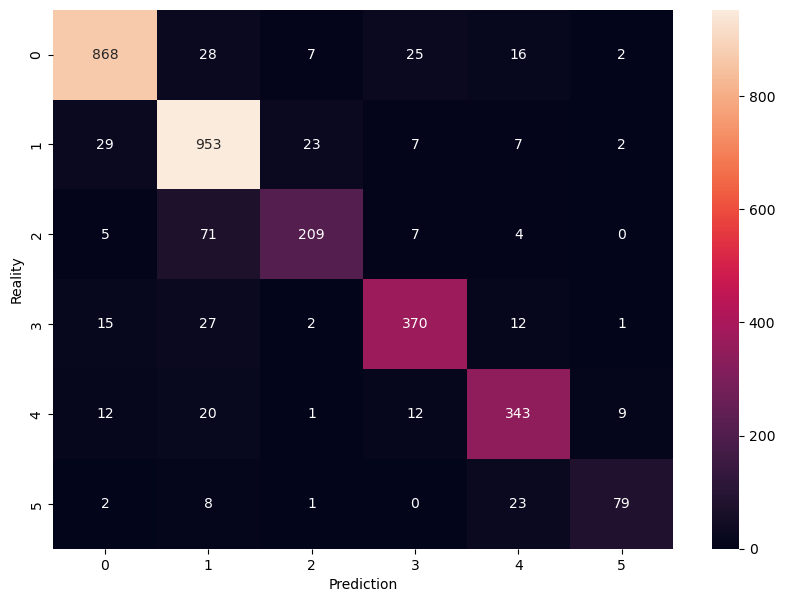

In [ ]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

# Predicciones
predictions_rf = classifier.predict(X_test)

# Rendimiento
accuracy_rf = accuracy_score(y_test, predictions_rf)
precision_rf = precision_score(y_test, predictions_rf, average='micro')
print("Precision : ", precision_rf)
print("Recall : ", recall_score(y_test, predictions_rf, average='micro'))
print("Accuracy Score : ", accuracy_rf)
print("F1 Score : ", f1_score(y_test, predictions_rf, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_rf), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Ridge

Precision :  0.8853125
Recall :  0.8853125
Accuracy Score :  0.8853125
F1 Score :  0.8853125


Text(95.72222222222221, 0.5, 'Reality')

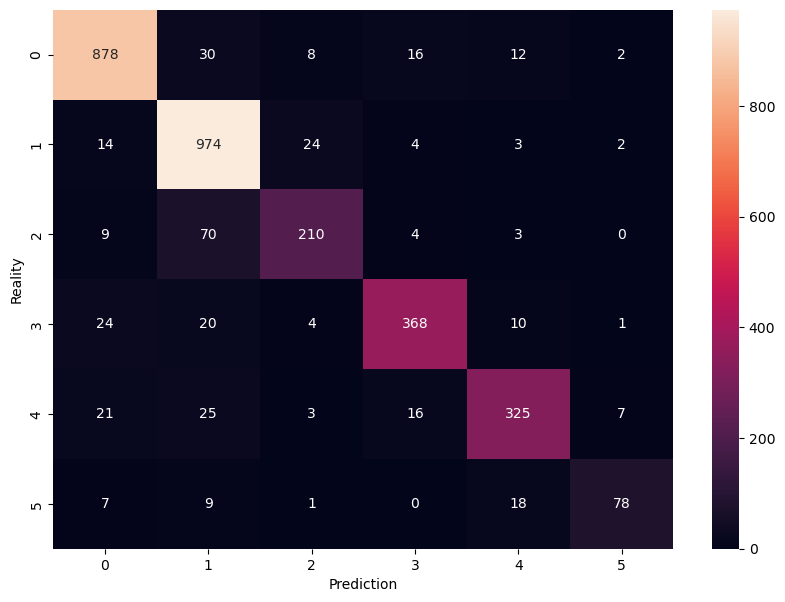

In [ ]:
from sklearn.linear_model import RidgeClassifier

classifier = RidgeClassifier()
classifier.fit(X_train, y_train)

# Predicciones
predictions_r = classifier.predict(X_test)

# Rendimiento
accuracy_r = accuracy_score(y_test, predictions_r)
precision_r = precision_score(y_test, predictions_r, average='micro')
print("Precision : ", precision_r)
print("Recall : ", recall_score(y_test, predictions_r, average='micro'))
print("Accuracy Score : ", accuracy_r)
print("F1 Score : ", f1_score(y_test, predictions_r, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_r), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Linear Support Vector Machine

Precision :  0.8878125
Recall :  0.8878125
Accuracy Score :  0.8878125
F1 Score :  0.8878125


Text(95.72222222222221, 0.5, 'Reality')

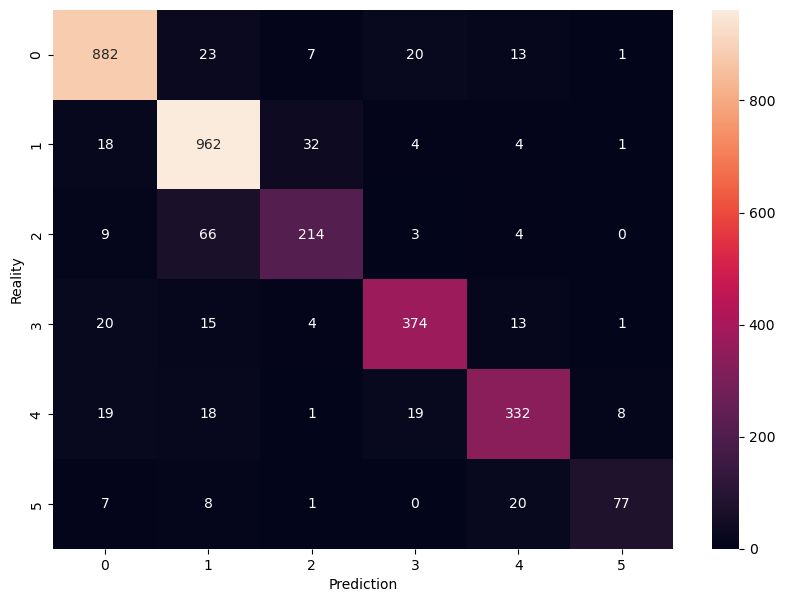

In [ ]:
from sklearn.svm import LinearSVC

classifier = LinearSVC()
classifier.fit(X_train, y_train)

# Predicciones
predictions_svc = classifier.predict(X_test)

# Rendimiento
accuracy_svc = accuracy_score(y_test, predictions_svc)
precision_svc = precision_score(y_test, predictions_svc, average='micro')
print("Precision : ", precision_svc)
print("Recall : ", recall_score(y_test, predictions_svc, average='micro'))
print("Accuracy Score : ", accuracy_svc)
print("F1 Score : ", f1_score(y_test, predictions_svc, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_svc), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Extra Trees

Precision :  0.890625
Recall :  0.890625
Accuracy Score :  0.890625
F1 Score :  0.890625


Text(95.72222222222221, 0.5, 'Reality')

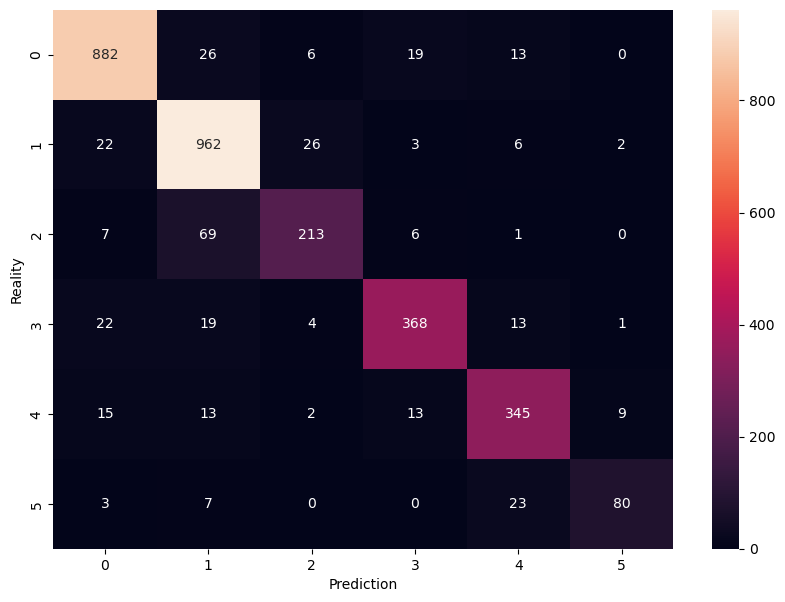

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

classifier = ExtraTreesClassifier()
classifier.fit(X_train, y_train)

# Predicciones
predictions_et = classifier.predict(X_test)

# Rendimiento
accuracy_et = accuracy_score(y_test, predictions_et)
precision_et = precision_score(y_test, predictions_et, average='micro')
print("Precision : ", precision_et)
print("Recall : ", recall_score(y_test, predictions_et, average='micro'))
print("Accuracy Score : ", accuracy_et)
print("F1 Score : ", f1_score(y_test, predictions_et, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_et), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

##### Clasificador Stochastic Gradient Descent

Precision :  0.889375
Recall :  0.889375
Accuracy Score :  0.889375
F1 Score :  0.889375


d:\Programs\anaconda3\lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Text(95.72222222222221, 0.5, 'Reality')

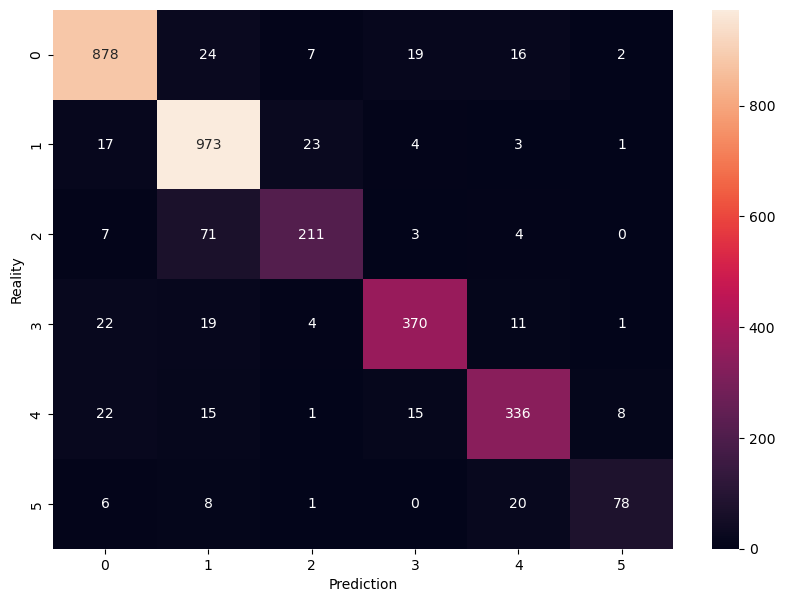

In [ ]:
from sklearn.linear_model import SGDClassifier

classifier = SGDClassifier(loss='hinge', max_iter=5)
classifier.fit(X_train, y_train)

# Predicciones
predictions_sgd = classifier.predict(X_test)

# Rendimiento
accuracy_sgd = accuracy_score(y_test, predictions_sgd)
precision_sgd = precision_score(y_test, predictions_sgd, average='micro')
print("Precision : ", precision_sgd)
print("Recall : ", recall_score(y_test, predictions_sgd, average='micro'))
print("Accuracy Score : ", accuracy_sgd)
print("F1 Score : ", f1_score(y_test, predictions_sgd, average='micro'))

# Matriz de confusión
plt.figure(figsize=(10,7))
sn.heatmap(confusion_matrix(y_test, predictions_sgd), annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Reality')

### Comparación de modelos

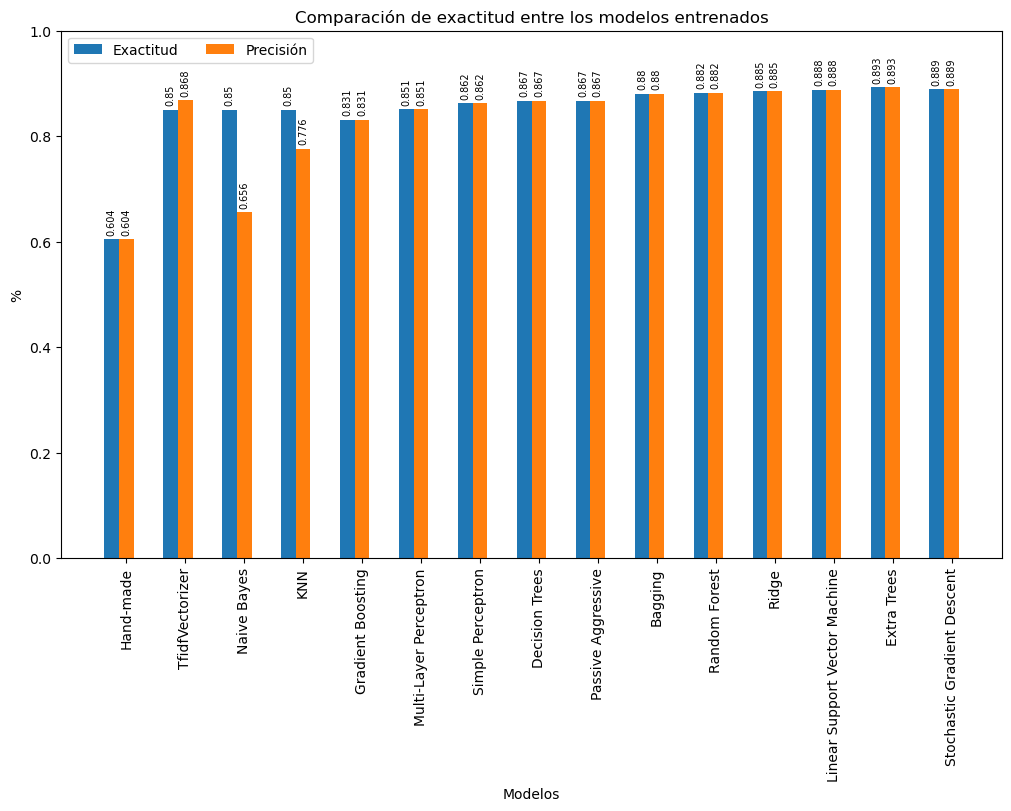

In [ ]:
models = ['Hand-made', 'TfidfVectorizer', 'Naive Bayes', 'KNN', 'Gradient Boosting','Multi-Layer Perceptron',
          'Simple Perceptron', 'Decision Trees', 'Passive Aggressive', 'Bagging', 'Random Forest', 'Ridge',
          'Linear Support Vector Machine', 'Extra Trees', 'Stochastic Gradient Descent']
accuracies = [accuracy_handmade, accuracy_tf, accuracy_nb, accuracy_knn, accuracy_gb, accuracy_mlp,
              accuracy_sp, accuracy_dt, accuracy_pa, accuracy_b, accuracy_rf, accuracy_r,
              accuracy_svc, accuracy_et, accuracy_sgd]

accuracies = list(np.around(np.array(accuracies), 3))

precisions = [precision_handmade, precision_tf, precision_nb, precision_knn, precision_gb, precision_mlp,
              precision_sp, precision_dt, precision_pa, precision_b, precision_rf, precision_r,
              precision_svc, precision_et, precision_sgd]

precisions = list(np.around(np.array(precisions), 3))

measurements = {
    'Exactitud': accuracies,
    'Precisión': precisions,
}

x = np.arange(len(models))
width = 0.25
multiplier = 0

fig, ax = plt.subplots(layout='constrained', figsize=(10,8)
                       )

for attribute, measurement in measurements.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3, fontsize=7, rotation='vertical')
    multiplier += 1

'''
#fig = plt.figure(figsize=(10,3))
plt.bar(models, accuracies, edgecolor='black', linewidth=1.0, color=['red', 'pink', 'blue', 'yellow', 'magenta', '#1f77b4',
                                   '#ff7f0e', '#2ca02c', '#d62728', '#9467bd','#8c564b', '#e377c2',
                                   '#7f7f7f', '#bcbd22', '#17becf'])
plt.xlabel('Modelos')
plt.xticks(fontsize=8, rotation=
           #87
           'vertical'
           )
#ax = fig.add_subplot(1)
#ax.set_xlim(-1,10)
#plt.setp(ax.get_xticklabels(), fontsize=10, rotation=60)
'''
ax.set_ylabel('%')
ax.set_xlabel('Modelos')
ax.set_title('Comparación de exactitud entre los modelos entrenados')
##plt.ylim([0, 1])
ax.set_xticks(x + width, models, fontsize=10, rotation='vertical')
ax.legend(loc='upper left', ncols=2)
ax.set_ylim(0,1)
plt.show()

### Prueba de un buen modelo

In [ ]:
prueba = ["this made feel hopeless",
          "it was the best party ever",
          "you are so loving",
          "you are so stubborn i hate you",
          "it scared the shit out of me, i'm afraid",
          "it was really amazing",
          "eating tacos",
          ]

x = tfidf.transform(prueba)
P = classifier.predict(x)
target_mapeo = {0: 'Tristeza', 1: 'Felicidad', 2: 'Amor', 3: 'Molestia', 4: 'Miedo', 5: 'Sorpresa'}

for i in range(len(prueba)):
  sentimiento = target_mapeo[int(P[i])]
  print(f"El tweet '{prueba[i]}' tiene un contexto de: {sentimiento}")

El tweet 'this made feel hopeless' tiene un contexto de: Tristeza
El tweet 'it was the best party ever' tiene un contexto de: Felicidad
El tweet 'you are so loving' tiene un contexto de: Amor
El tweet 'you are so stubborn i hate you' tiene un contexto de: Molestia
El tweet 'it scared the shit out of me, i'm afraid' tiene un contexto de: Miedo
El tweet 'it was really amazing' tiene un contexto de: Felicidad
El tweet 'eating tacos' tiene un contexto de: Felicidad
